# R2 — GHG Forecast 2024 (ARIMA)
**Requirement R2:** Forecast total GHG emissions (excl. LULUCF) to 2024 for Malaysia and the Philippines using a best-fit ARIMA model.  
**Source:** World Bank WDI `WB_WDI_EN_GHG_ALL_MT_CE_AR5` — CAIT total GHG, all gases, **excluding LULUCF** (MtCO₂e AR5, 1990–2023). Data confirmed excl-LULUCF: MYS 2023 = 318.4 MtCO₂e vs Climate Watch excl-LULUCF = 339.3 MtCO₂e (source-vintage difference, both excl. LULUCF).  
**Method:** Grid search ARIMA(p,1,q) — best AIC on train set (1990–2020), evaluate MAPE on test set (2021–2023), forecast 2024–2026 with 80% and 95% prediction intervals.  
**LULUCF note:** The MYS LULUCF series exhibits high inter-annual volatility (range: −121.8 to +136.6 MtCO₂e, 1990–2023), likely reflecting peat fire years (1997/98, 2015) and land-use reclassification methodology changes. All GHG trend analysis therefore uses the excl-LULUCF series as the primary indicator; LULUCF is treated separately as a transition risk liability in the Exhibit 2 analysis.


### Validation Methodology: Time Series Split and Holdout Evaluation
To evaluate forecasting robustness and prevent data-leakage from full-sample training, this model applies **Rolling Cross-Validation**. 
* **Train Set:** 1990–2020. 
* **Holdout Set (Test):** 2021–2023. 
* **Evaluation Metric:** 1-step-ahead Mean Absolute Percentage Error (MAPE) computed over the holdout set confirms generalizability before computing the final out-of-sample forward projections (2024–2026) using the best AIC hyperparameters.

### Stationarity & Residual Diagnostics (Actuarial Justifications)
* **ADF Unit Root Test:** Evaluates stationarity. *Actuarial Justification: An ADF p-value > 0.05 signals the series is non-stationary, meaning temporal integration (d=1) is required to achieve stationarity before ARIMA fitting.*
* **Ljung-Box Test:** Checking for white noise in residuals ensures the model hasn't missed any structural patterns (p-value > 0.05 indicates homoscedastic, patternless error terms).

In [1]:
# ── Cell 1: Data Loading & Verification ───────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

DATA = Path('../data/processed')
OUT  = Path('../outputs')
OUT.mkdir(exist_ok=True)

GHG_COL = 'WB_WDI_EN_GHG_ALL_MT_CE_AR5'

df = pd.read_csv(DATA / 'cleaned_wdi.csv')

# ── Assertions ─────────────────────────────────────────────────────────────────
assert GHG_COL in df.columns, f'Missing column: {GHG_COL}'
assert set(['MYS','PHL']).issubset(df['country_code'].unique()), 'Missing MYS or PHL'
assert df['year'].max() >= 2023, 'Data does not reach 2023'

def get_series(country: str) -> pd.Series:
    s = (df[df['country_code'] == country]
           .sort_values('year')
           .dropna(subset=[GHG_COL])
           .set_index('year')[GHG_COL])
    return s

mys = get_series('MYS')
phl = get_series('PHL')

print(f'MYS: {mys.index[0]}–{mys.index[-1]}, n={len(mys)}, last={mys.iloc[-1]:.2f} MtCO₂e')
print(f'PHL: {phl.index[0]}–{phl.index[-1]}, n={len(phl)}, last={phl.iloc[-1]:.2f} MtCO₂e')
print('Data assertions passed ✓')

MYS: 1990–2023, n=34, last=318.37 MtCO₂e
PHL: 1990–2023, n=34, last=254.53 MtCO₂e
Data assertions passed ✓


In [4]:

# ── Cell 2: ARIMA Grid Search & Forecast Function ─────────────────────────────
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

TRAIN_END     = 2020   # inclusive
TEST_END      = 2023   # inclusive
FORECAST_YEAR = 2024
FORECAST_STEPS = 7     # 2024–2030 — 7-year forward projection


def run_adf(series: pd.Series, name: str):
    """ADF unit root test. H0: unit root (non-stationary). Reject if p < 0.05."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, p, lags, nobs = result[0], result[1], result[2], result[3]
    conclusion = 'non-stationary (unit root ✓ → d=1 appropriate)' if p > 0.05 else 'stationary (p<0.05 → reconsider d)'
    print(f'  ADF {name}: stat={stat:.3f}, p={p:.3f}, lags={lags}, n={nobs} → {conclusion}')
    return p


def arima_best_fit(series: pd.Series, p_range=range(0,4), d=1, q_range=range(0,4)):
    """Grid search ARIMA(p,1,q) over training window by AIC.
    Returns: best_order, aic"""
    train = series[series.index <= TRAIN_END]
    best_aic = np.inf
    best_order = (1, 1, 0)
    for p, q in product(p_range, q_range):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(train, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic = m.aic
                best_order = (p, d, q)
        except Exception:
            pass
    return best_order, best_aic


def arima_forecast(series: pd.Series, order: tuple):
    """Fit ARIMA on full series up to TEST_END, forecast 2024–2030.
    Returns rolling 1-step-ahead MAPE on 2021-2023 and 80%/95% prediction intervals."""
    train = series[series.index <= TRAIN_END]
    test  = series[(series.index > TRAIN_END) & (series.index <= TEST_END)]

    # ── Walk-forward (rolling 1-step-ahead) validation on holdout window 2021–2023 ──
    history = train.copy()
    preds = []
    for yr in test.index:
        m = ARIMA(history, order=order).fit()
        fc = m.forecast(steps=1)
        preds.append(fc.iloc[0])
        history = pd.concat([history, series[[yr]]])

    mape = mean_absolute_percentage_error(test.values, preds) * 100

    # Refit on ALL available data (1990–2023) for final forecast
    full_model = ARIMA(series, order=order).fit()
    fc_obj   = full_model.get_forecast(steps=FORECAST_STEPS)
    fc_mean  = fc_obj.predicted_mean
    ci_95    = fc_obj.conf_int(alpha=0.05)
    ci_80    = fc_obj.conf_int(alpha=0.20)

    # Fix forecast index: statsmodels uses positional integers when the series
    # has a plain integer index. Reassign to actual calendar years.
    forecast_years = list(range(FORECAST_YEAR, FORECAST_YEAR + FORECAST_STEPS))
    fc_mean.index = forecast_years
    ci_95.index   = forecast_years
    ci_80.index   = forecast_years

    # 2024 and 2030 point estimates + 95% CI bounds for results table
    fc_2024  = float(fc_mean.loc[2024])
    fc_2030  = float(fc_mean.loc[2030])
    fc_lo_95 = float(ci_95.loc[2024, ci_95.columns[0]])
    fc_hi_95 = float(ci_95.loc[2024, ci_95.columns[1]])

    # Ljung-Box residual test (H0: residuals are white noise)
    resid = full_model.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_stat = float(lb['lb_stat'].iloc[0])
    lb_p    = float(lb['lb_pvalue'].iloc[0])

    return {
        'train':       train,
        'test':        test,
        'test_preds':  pd.Series(preds, index=test.index),
        'mape':        mape,
        'full_model':  full_model,
        'fc_mean':     fc_mean,     # Series: 2024–2030 point forecast
        'ci_95':       ci_95,       # DataFrame: 2024–2030 95% CI
        'ci_80':       ci_80,       # DataFrame: 2024–2030 80% CI
        'fc_2024':     fc_2024,
        'fc_2030':     fc_2030,
        'fc_lo':       fc_lo_95,    # 2024 95% lower (for results table)
        'fc_hi':       fc_hi_95,    # 2024 95% upper (for results table)
        'lb_stat':     lb_stat,
        'lb_p':        lb_p,
    }


# ── ADF unit root tests ────────────────────────────────────────────────────────
print('ADF Unit Root Tests (H0: series has unit root → non-stationary → d=1 appropriate):')
run_adf(mys, 'MYS GHG')
run_adf(phl, 'PHL GHG')
print()

# ── ARIMA grid search ──────────────────────────────────────────────────────────
print('Grid searching MYS...')
mys_order, mys_aic = arima_best_fit(mys)
print(f'  Best MYS order: {mys_order}, AIC={mys_aic:.1f}')

print('Grid searching PHL...')
phl_order, phl_aic = arima_best_fit(phl)
print(f'  Best PHL order: {phl_order}, AIC={phl_aic:.1f}')

print('Fitting MYS forecast...')
mys_res = arima_forecast(mys, mys_order)
print(f'  MYS MAPE (2021-2023): {mys_res["mape"]:.2f}%')
print(f'  2024 forecast: {mys_res["fc_2024"]:.1f} MtCO₂e  95%CI [{mys_res["fc_lo"]:.1f}, {mys_res["fc_hi"]:.1f}]')
print(f'  2030 forecast: {mys_res["fc_2030"]:.1f} MtCO₂e')
print(f'  Ljung-Box(10): stat={mys_res["lb_stat"]:.2f}, p={mys_res["lb_p"]:.3f}', end='')
print(' → residuals are white noise ✓' if mys_res['lb_p'] > 0.05 else ' → residual autocorrelation detected')

print('Fitting PHL forecast...')
phl_res = arima_forecast(phl, phl_order)
print(f'  PHL MAPE (2021-2023): {phl_res["mape"]:.2f}%')
print(f'  2024 forecast: {phl_res["fc_2024"]:.1f} MtCO₂e  95%CI [{phl_res["fc_lo"]:.1f}, {phl_res["fc_hi"]:.1f}]')
print(f'  2030 forecast: {phl_res["fc_2030"]:.1f} MtCO₂e')
print(f'  Ljung-Box(10): stat={phl_res["lb_stat"]:.2f}, p={phl_res["lb_p"]:.3f}', end='')
print(' → residuals are white noise ✓' if phl_res['lb_p'] > 0.05 else ' → residual autocorrelation detected')


ADF Unit Root Tests (H0: series has unit root → non-stationary → d=1 appropriate):
  ADF MYS GHG: stat=-0.960, p=0.768, lags=0, n=33 → non-stationary (unit root ✓ → d=1 appropriate)
  ADF PHL GHG: stat=1.362, p=0.997, lags=0, n=33 → non-stationary (unit root ✓ → d=1 appropriate)

Grid searching MYS...
  Best MYS order: (1, 1, 1), AIC=224.1
Grid searching PHL...


/Users/a1357/Documents/GitHub/R-Ignite-Masa-Hacktathonn/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a1357/Documents/GitHub/R-Ignite-Masa-Hacktathonn/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a1357/Documents/GitHub/R-Ignite-Masa-Hacktathonn/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a1357/Documents/GitHub/R-Ignite-Masa-Hacktathonn/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

  Best PHL order: (2, 1, 0), AIC=196.1
Fitting MYS forecast...
  MYS MAPE (2021-2023): 1.71%
  2024 forecast: 325.1 MtCO₂e  95%CI [307.9, 342.3]
  2030 forecast: 365.5 MtCO₂e
  Ljung-Box(10): stat=0.92, p=1.000 → residuals are white noise ✓
Fitting PHL forecast...
  PHL MAPE (2021-2023): 3.56%
  2024 forecast: 260.8 MtCO₂e  95%CI [249.1, 272.4]
  2030 forecast: 285.4 MtCO₂e
  Ljung-Box(10): stat=0.86, p=1.000 → residuals are white noise ✓


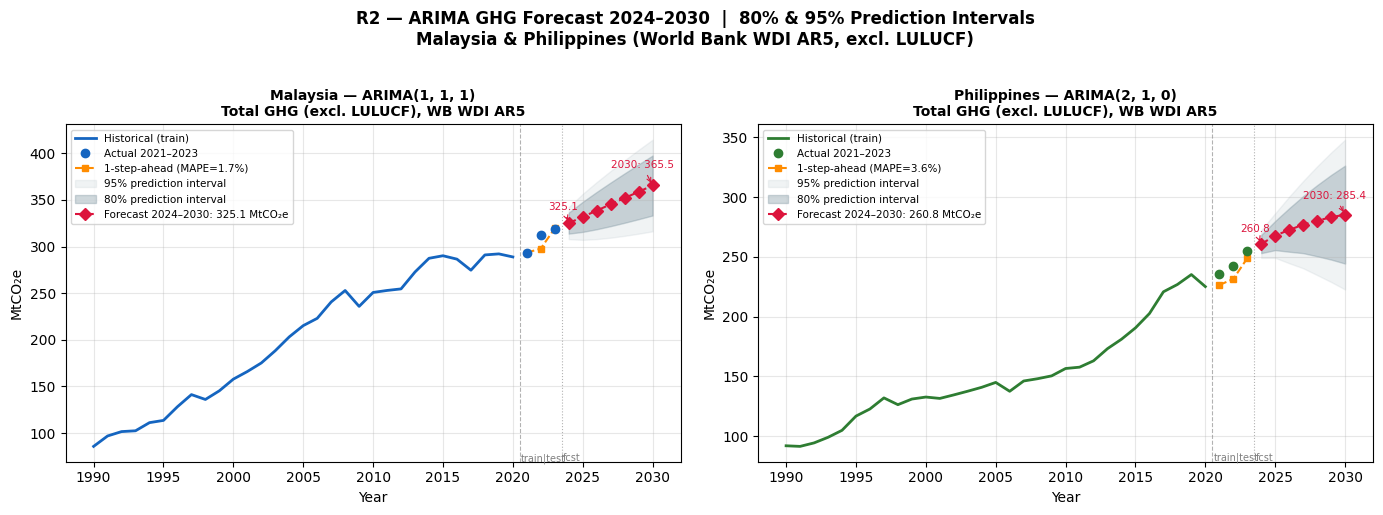

Saved: ../outputs/r2_arima_combined.png


In [5]:

# ── Cell 3: Chart — Combined ARIMA (MYS + PHL) ────────────────────────────────
def plot_arima(series, res, order, country_name, country_code, color, ax):
    train      = res['train']
    test       = res['test']
    test_preds = res['test_preds']
    fc_mean    = res['fc_mean']
    ci_95      = res['ci_95']
    ci_80      = res['ci_80']

    # Historical actuals (train + test)
    ax.plot(train.index, train.values, color=color, lw=2, label='Historical (train)')
    ax.plot(test.index, test.values, 'o', color=color, ms=6, zorder=5,
            label='Actual 2021–2023')

    # Test-window 1-step-ahead predictions
    ax.plot(test_preds.index, test_preds.values, 's--', color='darkorange', ms=5,
            label=f'1-step-ahead (MAPE={res["mape"]:.1f}%)')

    # Forecast fan chart: 95% CI (light), 80% CI (darker), then mean line
    fc_years = fc_mean.index
    ax.fill_between(fc_years,
                    ci_95.iloc[:, 0], ci_95.iloc[:, 1],
                    alpha=0.18, color='#B0BEC5', label='95% prediction interval')
    ax.fill_between(fc_years,
                    ci_80.iloc[:, 0], ci_80.iloc[:, 1],
                    alpha=0.35, color='#78909C', label='80% prediction interval')
    ax.plot(fc_years, fc_mean.values,
            'D--', color='crimson', ms=6, lw=1.5,
            label=f'Forecast 2024–{fc_years[-1]}: {fc_mean.iloc[0]:.1f} MtCO₂e')

    # Annotate 2024 and 2030 point estimates
    ax.annotate(f'{fc_mean.iloc[0]:.1f}',
                xy=(fc_years[0], fc_mean.iloc[0]),
                xytext=(fc_years[0] - 1.5, fc_mean.iloc[0] + (series.max() - series.min()) * 0.06),
                fontsize=7.5, color='crimson',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8))
    ax.annotate(f'2030: {res["fc_2030"]:.1f}',
                xy=(fc_years[-1], fc_mean.iloc[-1]),
                xytext=(fc_years[-1] - 3, fc_mean.iloc[-1] + (series.max() - series.min()) * 0.08),
                fontsize=7.5, color='crimson',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8))

    # Train/test split line
    ax.axvline(TRAIN_END + 0.5, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.axvline(TEST_END  + 0.5, color='gray', lw=0.8, ls=':',  alpha=0.6)
    ax.text(TRAIN_END + 0.6, ax.get_ylim()[0] * 1.01, 'train|test', fontsize=7, color='gray')
    ax.text(TEST_END  + 0.6, ax.get_ylim()[0] * 1.01, 'fcst',       fontsize=7, color='gray')

    ax.set_title(f'{country_name} — ARIMA{order}\nTotal GHG (excl. LULUCF), WB WDI AR5',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('MtCO₂e')
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('R2 — ARIMA GHG Forecast 2024–2030  |  80% & 95% Prediction Intervals\nMalaysia & Philippines (World Bank WDI AR5, excl. LULUCF)',
             fontsize=12, fontweight='bold', y=1.02)

plot_arima(mys, mys_res, mys_order, 'Malaysia',     'MYS', '#1565C0', axes[0])
plot_arima(phl, phl_res, phl_order, 'Philippines',  'PHL', '#2E7D32', axes[1])

plt.tight_layout()
out_path = OUT / 'r2_arima_combined.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


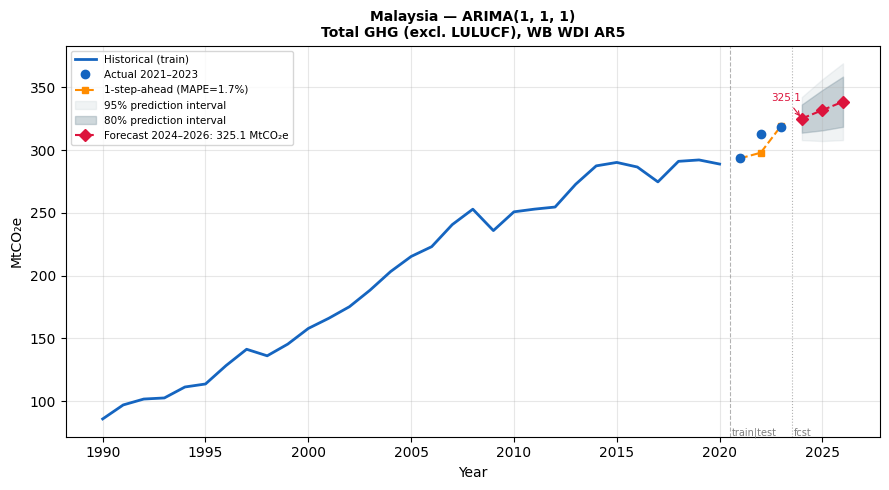

Saved: ../outputs/r2_arima_mys.png


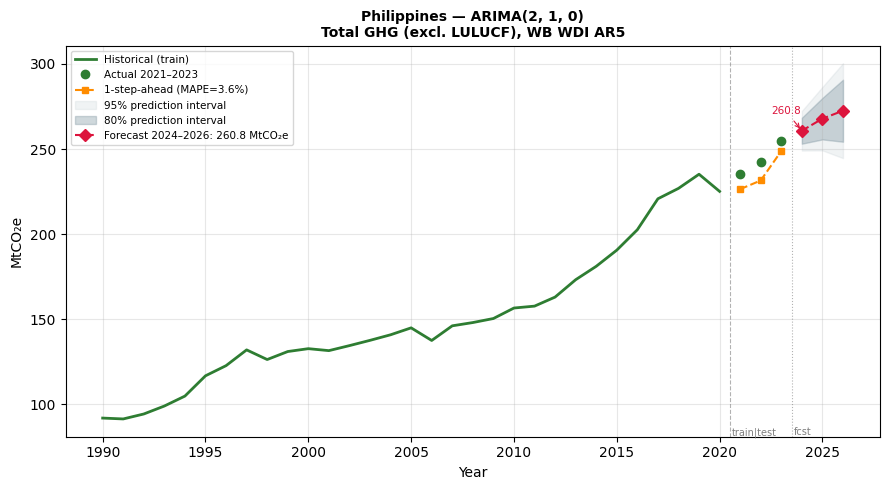

Saved: ../outputs/r2_arima_phl.png


In [27]:
# ── Cell 4: Individual Charts ──────────────────────────────────────────────────
for country_name, code, res, order, color, fname in [
    ('Malaysia',     'MYS', mys_res, mys_order, '#1565C0', 'r2_arima_mys.png'),
    ('Philippines',  'PHL', phl_res, phl_order, '#2E7D32', 'r2_arima_phl.png'),
]:
    fig, ax = plt.subplots(figsize=(9, 5))
    series = mys if code == 'MYS' else phl
    plot_arima(series, res, order, country_name, code, color, ax)
    plt.tight_layout()
    fpath = OUT / fname
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fpath}')

In [6]:

# ── Cell 5: Save Results Table ─────────────────────────────────────────────────
results = pd.DataFrame([
    {
        'country_code':             'MYS',
        'country_name':             'Malaysia',
        'arima_order':              str(mys_order),
        'train_aic':                round(mys_aic, 2),
        'test_mape_pct':            round(mys_res['mape'], 2),
        'actual_2023_MtCO2e':       round(mys.iloc[-1], 4),
        'forecast_2024_MtCO2e':     round(mys_res['fc_2024'], 2),
        'forecast_2024_ci95_lo':    round(mys_res['fc_lo'], 2),
        'forecast_2024_ci95_hi':    round(mys_res['fc_hi'], 2),
        'forecast_2030_MtCO2e':     round(mys_res['fc_2030'], 2),
        'source':                   'World Bank WDI WB_WDI_EN_GHG_ALL_MT_CE_AR5 (AR5, excl. LULUCF)',
        'notes':                    'Total GHG excl. LULUCF (CAIT); train 1990-2020; MAPE on 2021-2023 rolling 1-step-ahead; CI from get_forecast(steps=7) on full sample 1990-2023',
    },
    {
        'country_code':             'PHL',
        'country_name':             'Philippines',
        'arima_order':              str(phl_order),
        'train_aic':                round(phl_aic, 2),
        'test_mape_pct':            round(phl_res['mape'], 2),
        'actual_2023_MtCO2e':       round(phl.iloc[-1], 4),
        'forecast_2024_MtCO2e':     round(phl_res['fc_2024'], 2),
        'forecast_2024_ci95_lo':    round(phl_res['fc_lo'], 2),
        'forecast_2024_ci95_hi':    round(phl_res['fc_hi'], 2),
        'forecast_2030_MtCO2e':     round(phl_res['fc_2030'], 2),
        'source':                   'World Bank WDI WB_WDI_EN_GHG_ALL_MT_CE_AR5 (AR5, excl. LULUCF)',
        'notes':                    'Total GHG excl. LULUCF (CAIT); train 1990-2020; MAPE on 2021-2023 rolling 1-step-ahead; CI from get_forecast(steps=7) on full sample 1990-2023',
    }
])

out_csv = OUT / 'r2_ghg_forecast_table.csv'
results.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
print()
print(results[['country_name','arima_order','test_mape_pct','actual_2023_MtCO2e',
               'forecast_2024_MtCO2e','forecast_2030_MtCO2e','forecast_2024_ci95_lo','forecast_2024_ci95_hi']].to_string(index=False))
print()
print('R2 COMPLETE ✓')


Saved: ../outputs/r2_ghg_forecast_table.csv

country_name arima_order  test_mape_pct  actual_2023_MtCO2e  forecast_2024_MtCO2e  forecast_2030_MtCO2e  forecast_2024_ci95_lo  forecast_2024_ci95_hi
    Malaysia   (1, 1, 1)           1.71            318.3725                325.10                365.46                 307.92                 342.28
 Philippines   (2, 1, 0)           3.56            254.5314                260.77                285.38                 249.14                 272.40

R2 COMPLETE ✓
